In [7]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

In [17]:
from src.preprocessing.dataset_loader import build_dataset_index, get_label_from_folder

In [9]:
paths, labels = build_dataset_index(
    "../data/raw/train"
)

In [10]:

print(
    "Images:",
    len(paths)
)

print(
    "Labels:",
    len(labels)
)

Images: 5216
Labels: 5216


In [11]:
print(labels[:10])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [12]:
set(labels)

{0, 1}

In [13]:
from src.preprocessing.dataset_loader import (
    ChestXRayDataset
)

dataset = ChestXRayDataset(
    paths,
    labels
)

In [14]:
image, label = dataset[0]

print(type(image))
print(label)

<class 'PIL.Image.Image'>
0


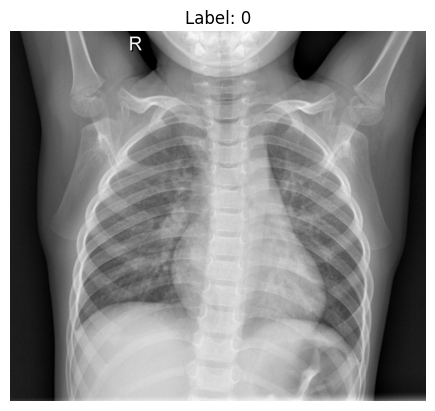

In [15]:
import matplotlib.pyplot as plt

image, label = dataset[0]

plt.imshow(
    image,
    cmap="gray"
)

plt.title(
    f"Label: {label}"
)

plt.axis("off")
plt.show()

In [18]:
print("Class Mapping")

print(
    "NORMAL ->",
    get_label_from_folder("NORMAL")
)

print(
    "PNEUMONIA ->",
    get_label_from_folder("PNEUMONIA")
)

Class Mapping
NORMAL -> 0
PNEUMONIA -> 1


In [19]:
from sklearn.model_selection import train_test_split
import pandas as pd

In [20]:
from src.preprocessing.dataset_loader import (
    build_dataset_index
)

train_paths, train_labels = build_dataset_index(
    "../data/raw/train"
)

print(len(train_paths))
print(len(train_labels))

5216
5216


In [21]:
X_train, X_val, y_train, y_val = train_test_split(
    train_paths,
    train_labels,
    test_size=0.20,
    random_state=42,
    stratify=train_labels
)

In [22]:
print("Train Images:", len(X_train))
print("Validation Images:", len(X_val))

Train Images: 4172
Validation Images: 1044


In [23]:
from collections import Counter

print("Training Distribution")
print(Counter(y_train))

print()

print("Validation Distribution")
print(Counter(y_val))

Training Distribution
Counter({1: 3099, 0: 1073})

Validation Distribution
Counter({1: 776, 0: 268})


In [24]:
train_df = pd.DataFrame({
    "Image": X_train,
    "Label": y_train
})

val_df = pd.DataFrame({
    "Image": X_val,
    "Label": y_val
})

In [25]:
summary = pd.DataFrame({
    "Split": ["Train", "Validation"],
    "Images": [
        len(X_train),
        len(X_val)
    ]
})

summary

,Split,Images
0,Train,4172
1,Validation,1044


In [26]:
def class_percentage(labels):

    counts = Counter(labels)

    total = len(labels)

    return {
        "NORMAL %":
            round(
                counts[0] / total * 100,
                2
            ),
        "PNEUMONIA %":
            round(
                counts[1] / total * 100,
                2
            )
    }

In [27]:
print(class_percentage(y_train))
print(class_percentage(y_val))

{'NORMAL %': 25.72, 'PNEUMONIA %': 74.28}
{'NORMAL %': 25.67, 'PNEUMONIA %': 74.33}


In [28]:
import matplotlib.pyplot as plt

train_counts = Counter(y_train)
val_counts = Counter(y_val)

labels = ["NORMAL", "PNEUMONIA"]

train_values = [
    train_counts[0],
    train_counts[1]
]

val_values = [
    val_counts[0],
    val_counts[1]
]

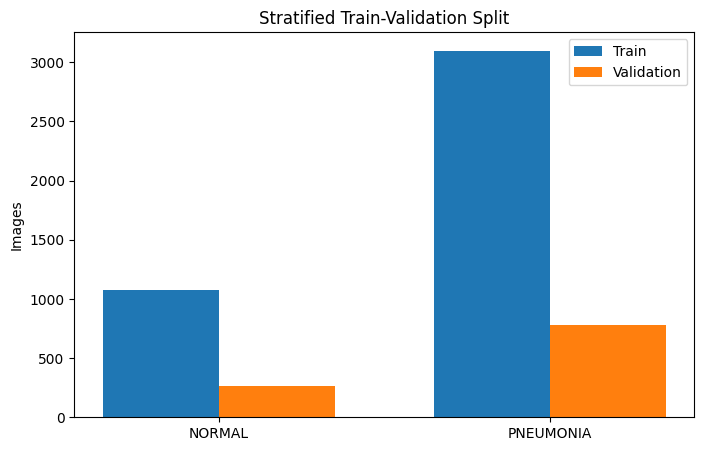

In [29]:
import numpy as np

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    x - width/2,
    train_values,
    width,
    label="Train"
)

plt.bar(
    x + width/2,
    val_values,
    width,
    label="Validation"
)

plt.xticks(x, labels)

plt.ylabel("Images")

plt.title(
    "Stratified Train-Validation Split"
)

plt.legend()

plt.show()

In [30]:
plt.savefig(
    "../results/figures/stratified_split.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [31]:
split_summary = pd.DataFrame({

    "Dataset": [
        "Train",
        "Validation"
    ],

    "Images": [
        len(X_train),
        len(X_val)
    ],

    "Normal": [
        train_counts[0],
        val_counts[0]
    ],

    "Pneumonia": [
        train_counts[1],
        val_counts[1]
    ]
})

split_summary

,Dataset,Images,Normal,Pneumonia
0,Train,4172,1073,3099
1,Validation,1044,268,776


In [32]:
split_summary.to_csv(
    "../results/metrics/stratified_split_summary.csv",
    index=False
)

In [33]:
import pickle

split_data = {

    "X_train": X_train,
    "y_train": y_train,

    "X_val": X_val,
    "y_val": y_val
}

In [34]:
with open(
    "../results/metrics/train_val_split.pkl",
    "wb"
) as f:

    pickle.dump(
        split_data,
        f
    )

The original validation set contained only
16 images and was deemed insufficient for
robust model evaluation.

A stratified train-validation split was
performed on the training dataset using
an 80:20 ratio.

Stratification preserved the original
class distribution while providing a
substantially larger validation set.

The original test set was retained
unchanged for final evaluation.